<a href="https://colab.research.google.com/github/galiya19/Scheduler-/blob/main/A_day_in_a_life_of_a_Minervan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#GREEDY APPROACH

class MinHeapq:
    """
    A class to represent a Min-Heap priority queue.
    Used to prioritize tasks according to their priority values.
    """

    def __init__(self):
        """
        empty Min-Heap
        Attributes:
        - heap: List to store heap elements.
        """
        self.heap = []

    def left(self, i):
        """
        Returns the index of the left child of the node at index i.
        """
        return 2 * i + 1

    def right(self, i):
        """
        Returns the index of the right child of the node at index i.
        """
        return 2 * i + 2

    def parent(self, i):
        """
        Returns the index of the parent of the node at index i.
        """
        return (i - 1) // 2

    def heappush(self, key):
        """
        Inserting a new element into the Min-Heap and maintains the heap property
        """
        self.heap.append(key)  # Add the new key to the end
        index = len(self.heap) - 1
        #move the new key up to maintain the min-heap property
        while index > 0 and self.heap[self.parent(index)] > self.heap[index]:
            self.heap[index], self.heap[self.parent(index)] = self.heap[self.parent(index)], self.heap[index]
            index = self.parent(index)

    def heapify(self, i):
        """
        Ensures the subtree rooted at index i satisfies the min-heap property
        """
        smallest = i
        l = self.left(i)
        r = self.right(i)
        n = len(self.heap)

        if l < n and self.heap[l] < self.heap[smallest]:
            smallest = l

        if r < n and self.heap[r] < self.heap[smallest]:
            smallest = r

        if smallest != i:
            self.heap[i], self.heap[smallest] = self.heap[smallest], self.heap[i]
            self.heapify(smallest)

    def heappop(self):
        """
        Removes and returns the minimum element from the Min-Heap.
        """
        if not self.heap:
            raise ValueError("Error: There are no elements in the heap")

        min_e = self.heap[0]  #root element is the minimum
        self.heap[0] = self.heap[-1]  #move the last element to the root
        self.heap.pop()  #remove the last element

        if self.heap:
            self.heapify(0)  #restore the heap property

        return min_e

class Task:
    """
    Represents a task along with its metadata and utility calculations

    Attributes:
    ---------
    ID: str. (unique identifier for the task)
    Task description (str).
    Duration: int.(Duration of the task in minutes)
    dependencies: list of strings. (List of task IDs that must be completed prior to this task)
    Importance: integer.(The task's importance is scaled from one to ten)
    Probability of Success: Float(The likelihood of successfully completing the task, ranging from 0 to 1)
    Status: str.(The current status of the task ('N', 'I', or 'C'))
    Priority: float.(Utility-based task prioritization)
    """
    def __init__(self, id, description, duration, dependencies, importance=1, probability_of_success=1.0, status="N"):
        self.id = id
        self.description = description
        self.duration = duration
        self.dependencies = dependencies
        self.importance = importance  #importance of the task
        self.probability_of_success = probability_of_success  #from 0 to  1)
        self.status = status
        self.priority = 0  #default priority value

    def calculate_utility(self):
        """
        Calculates the utility of a task based on importance and duration
        Returns: float (utility value of the task)
        """
        #utility may depend on importance and duration (short tasks may be more valuable in this case)
        utility = self.importance / (self.duration if self.duration > 0 else 1)
        return utility

    def calculate_expected_utility(self):
        """
        Calculates the expected utility based on the probability of success
        Returns: float (expected utility value of the task)
        """
        utility = self.calculate_utility()
        expected_utility = utility * self.probability_of_success
        return expected_utility

    def calculate_priority(self):
        """
        Update the priority of the task based on its expected utility.
        """
        self.priority = self.calculate_expected_utility()

    def __lt__(self, other):
        """
        Compare tasks based on priority for min-heap placement.

        Parameters
        ----------
        other : Task
            Another task to compare against.

        Returns: bool (True if this task has higher priority than the other)
        """
        return self.priority > other.priority

class TaskScheduler:
    """
    Task scheduling system with dependency management and prioritization.
    The scheduler manages a set of tasks, respecting dependencies and maximizing
    utility within a given time constraint.

    Attributes
    ----------
    NOT_STARTED : str
        Status code indicating a task has not been started.
    IN_PRIORITY_QUEUE : str
        Status code indicating a task is in the priority queue.
    COMPLETED : str
        Status code indicating a task has been completed.
    tasks : list of Task
        List of all tasks to be scheduled.
    unscheduled_tasks : list of Task
        List of tasks that are yet to be scheduled.
    priority_queue : MinHeapq
        Priority queue to schedule tasks based on priority.
    buffer_time : int
        Additional time (in minutes) between tasks to account for transitions.
    total_utility : float
        Total utility accumulated by completing tasks.
    dependency_count : dict
        Map of task IDs to the number of dependencies each task has.
    dependency_graph : dict
        Adjacency list representation of task dependencies.

    """
    NOT_STARTED = 'N'
    IN_PRIORITY_QUEUE = 'I'
    COMPLETED = 'C'

    def __init__(self, tasks):
        """
        Initialize the TaskScheduler with a list of tasks.
        """
        self.tasks = tasks
        self.unscheduled_tasks = list(tasks)
        self.priority_queue = MinHeapq()
        self.buffer_time = 15
        self.total_utility = 0

        #Create a map for task dependencies
        self.dependency_count = {task.id: len(task.dependencies) for task in tasks}
        self.dependency_graph = {task.id: [] for task in tasks}

        #Build the dependency graph
        for task in tasks:
            for dep in task.dependencies:
                self.dependency_graph[dep].append(task.id)

    def get_tasks_ready(self):
        """
        Identify and enqueue tasks ready to be scheduled.
        """
        for task in list(self.unscheduled_tasks):
            if task.status == self.NOT_STARTED and self.dependency_count[task.id] == 0:
                task.calculate_priority()
                task.status = self.IN_PRIORITY_QUEUE
                self.priority_queue.heappush(task)
                self.unscheduled_tasks.remove(task)

    def remove_dependency(self, task_id):
        """
        Update dependency counts and make dependent tasks ready if possible.
        """
        for dependent in self.dependency_graph[task_id]:
            self.dependency_count[dependent] -= 1

    def check_unscheduled_tasks(self):
        """
        Returns True if there are unscheduled tasks remaining.
        """
        return any(task.status == self.NOT_STARTED for task in self.tasks)

    def format_time(self, time):
        """
        Formats time in hours and minutes.
        """
        return f"{time // 60}h{time % 60:02d}"

    def run_task_scheduler(self, starting_time, total_allowed_time):
        """
        Run the task scheduler to maximize utility within time constraints.

        Parameters
        ----------
        starting_time : int
            Start time of the scheduler in minutes.
        total_allowed_time : int
            Total time allowed for task scheduling in minutes.
        """
        current_time = starting_time
        total_time_spent = 0
        print("Running a scheduler with time constraints:\n")

        while (self.check_unscheduled_tasks() or len(self.priority_queue.heap) > 0) and total_time_spent < total_allowed_time:
            self.get_tasks_ready()

            if len(self.priority_queue.heap) == 0:
                print("No tasks can be scheduled due to unmet dependencies or time constraints.")
                break

            task = self.priority_queue.heappop()

                #check if the task can fit within the remaining time
            if total_time_spent + task.duration > total_allowed_time:
                print(f"⏳ Not enough time remaining to schedule '{task.description}'. Skipping!")
                continue

            print(f"🕰 t={self.format_time(current_time)}")
            print(f"\tStarted '{task.description}' for {task.duration} mins...")
            current_time += task.duration
            total_time_spent += task.duration
            print(f"\t✅ t={self.format_time(current_time)}, task completed!")

                #add buffer time if there is enough time remaining
            if total_time_spent + self.buffer_time <= total_allowed_time:
                    current_time += self.buffer_time
                    total_time_spent += self.buffer_time
                    print(f"⏳ Added a 15-minute buffer. Current time: {self.format_time(current_time)}")
            else:
                    print("⏳ Skipped buffer time due to time constraints.")

            self.total_utility += task.calculate_utility()
            task.status = self.COMPLETED
            self.remove_dependency(task.id)

        print(f"\n🏁 Scheduler completed. Total utility: {self.total_utility:.2f}")
        print(f"Total time spent: {self.format_time(total_time_spent)} out of {self.format_time(total_allowed_time)}.")

In [ ]:
tasks = [
    Task(id=0, description='make breakfast',
         duration=30, dependencies=[]),
    Task(id=1, description='Pre work for CS110',
         duration=90, dependencies=[0]),
    Task(id=2, description='Internship applications',
         duration=60, dependencies=[]),
    Task(id=3, description='Shopping at Taipei 101',
         duration=120, dependencies=[0]),
    Task(id=4, description='Mini hike at the elephant mountain',
         duration=90, dependencies=[3]),
    Task(id=5, description='Take a walk at the Ximending market',
         duration=40, dependencies=[4,6]),
    Task(id=6, description='Go to the gym',
         duration=90, dependencies=[7, 0]),
    Task(id=7, description='Clean the room',
         duration=15, dependencies=[2])
    ]

task_scheduler = TaskScheduler(tasks)

start_scheduler_at = 8*60
total_allowed_time = 9*60
task_scheduler.run_task_scheduler(start_scheduler_at, total_allowed_time)

Running a scheduler with time constraints:

🕰 t=8h00
	Started 'make breakfast' for 30 mins...
	✅ t=8h30, task completed!
⏳ Added a 15-minute buffer. Current time: 8h45
🕰 t=8h45
	Started 'Internship applications' for 60 mins...
	✅ t=9h45, task completed!
⏳ Added a 15-minute buffer. Current time: 10h00
🕰 t=10h00
	Started 'Clean the room' for 15 mins...
	✅ t=10h15, task completed!
⏳ Added a 15-minute buffer. Current time: 10h30
🕰 t=10h30
	Started 'Pre work for CS110' for 90 mins...
	✅ t=12h00, task completed!
⏳ Added a 15-minute buffer. Current time: 12h15
🕰 t=12h15
	Started 'Go to the gym' for 90 mins...
	✅ t=13h45, task completed!
⏳ Added a 15-minute buffer. Current time: 14h00
🕰 t=14h00
	Started 'Shopping at Taipei 101' for 120 mins...
	✅ t=16h00, task completed!
⏳ Added a 15-minute buffer. Current time: 16h15
⏳ Not enough time remaining to schedule 'Mini hike at the elephant mountain'. Skipping!
No tasks can be scheduled due to unmet dependencies or time constraints.

🏁 Scheduler comp

In [ ]:
#test case 2
tasks = [
    Task(0, "wake up", 10, []),
    Task(1, "Go for a run", 40, [0]),
    Task(2, "wash the dishes", 30, []),
    Task(3, "Study at Louisa coffee", 90, [0]),
    Task(4, "Visit hotsprings", 90, [3]),
    Task(5, "Take a walk at the Ximending market", 40, [4]),
    Task(6, "Go get the groceries", 60, [1]),
    Task(7, "Unpack groceries", 15, [6])
]

task_scheduler = TaskScheduler(tasks)

start_scheduler_at = 8*60
total_allowed_time = 5*60
task_scheduler.run_task_scheduler(start_scheduler_at, total_allowed_time)


Running a scheduler with time constraints:

🕰 t=8h00
	Started 'wake up' for 10 mins...
	✅ t=8h10, task completed!
⏳ Added a 15-minute buffer. Current time: 8h25
🕰 t=8h25
	Started 'wash the dishes' for 30 mins...
	✅ t=8h55, task completed!
⏳ Added a 15-minute buffer. Current time: 9h10
🕰 t=9h10
	Started 'Go for a run' for 40 mins...
	✅ t=9h50, task completed!
⏳ Added a 15-minute buffer. Current time: 10h05
🕰 t=10h05
	Started 'Go get the groceries' for 60 mins...
	✅ t=11h05, task completed!
⏳ Added a 15-minute buffer. Current time: 11h20
🕰 t=11h20
	Started 'Unpack groceries' for 15 mins...
	✅ t=11h35, task completed!
⏳ Added a 15-minute buffer. Current time: 11h50
⏳ Not enough time remaining to schedule 'Study at Louisa coffee'. Skipping!
No tasks can be scheduled due to unmet dependencies or time constraints.

🏁 Scheduler completed. Total utility: 0.24
Total time spent: 3h50 out of 5h00.


In [ ]:
#test case with less total_allowed_time
tasks = [
    Task(id=0, description='make breakfast',
         duration=30, dependencies=[]),
    Task(id=1, description='Pre work for CS110',
         duration=90, dependencies=[0]),
    Task(id=2, description='Internship applications',
         duration=60, dependencies=[]),
    Task(id=3, description='Shopping at Taipei 101',
         duration=120, dependencies=[0]),
    Task(id=4, description='Mini hike at the elephant mountain',
         duration=90, dependencies=[3]),
    Task(id=5, description='Take a walk at the Ximending market',
         duration=40, dependencies=[4,6]),
    Task(id=6, description='Go to the gym',
         duration=90, dependencies=[7, 0]),
    Task(id=7, description='Clean the room',
         duration=15, dependencies=[2])
    ]

task_scheduler = TaskScheduler(tasks)

start_scheduler_at = 8*60
total_allowed_time = 4*60
task_scheduler.run_task_scheduler(start_scheduler_at, total_allowed_time)

Running a scheduler with time constraints:

🕰 t=8h00
	Started 'make breakfast' for 30 mins...
	✅ t=8h30, task completed!
⏳ Added a 15-minute buffer. Current time: 8h45
🕰 t=8h45
	Started 'Internship applications' for 60 mins...
	✅ t=9h45, task completed!
⏳ Added a 15-minute buffer. Current time: 10h00
🕰 t=10h00
	Started 'Clean the room' for 15 mins...
	✅ t=10h15, task completed!
⏳ Added a 15-minute buffer. Current time: 10h30
🕰 t=10h30
	Started 'Pre work for CS110' for 90 mins...
	✅ t=12h00, task completed!
⏳ Skipped buffer time due to time constraints.

🏁 Scheduler completed. Total utility: 0.13
Total time spent: 4h00 out of 4h00.


In [ ]:
#DYNAMIC PROGRAMMING APPROACH

class Task:
    """
    Represents a task along with its metadata and utility calculations

    Attributes:
    ---------
    ID: str. (unique identifier for the task)
    Task description (str).
    Duration: int.(Duration of the task in minutes)
    dependencies: list of strings. (List of task IDs that must be completed prior to this task)
    Importance: integer.(The task's importance is scaled from one to ten)
    Probability of Success: Float(The likelihood of successfully completing the task, ranging from 0 to 1)
    Status: str.(The current status of the task ('N', 'I', or 'C'))
    Priority: float.(Utility-based task prioritization)
    """
    def __init__(self, id, description, duration, dependencies, importance=1, probability_of_success=1.0):
        """
        Initialize a task with metadata.

        Parameters
        ----------
        id : int (Unique identifier for the task)
        description : str (Description of the task)
        duration : int (Duration of the task in minutes)
        dependencies : list of int (List of task IDs that must be completed before this task)
        importance : int, optional (Importance of the task (default is 1))
        probability_of_success : float, optional (Probability of successfully completing the task (default is 1.0))
        """
        self.id = id
        self.description = description
        self.duration = duration
        self.dependencies = dependencies
        self.importance = importance
        self.probability_of_success = probability_of_success
        self.priority = 0
        self.utility = 0
        self.expected_utility = 0


    def calculate_utility(self):
        """
        Calculate the utility of the task based on its importance and duration.
        Updates the `utility` attribute.
        """
        self.utility = self.importance / self.duration if self.duration > 0 else 0

    def calculate_expected_utility(self):
        """
        Calculate and return the expected utility of the task.
        Returns
        -------
        float
            Expected utility, which is utility multiplied by probability of success.
        """
        self.expected_utility = self.utility * self.probability_of_success
        return self.expected_utility

    def calculate_priority(self):
        """
        Update the priority of the task based on its expected utility.
        Calls `calculate_utility` and `calculate_expected_utility` to update
        the `priority` attribute.
        """
        self.calculate_utility()
        self.calculate_expected_utility()
        self.priority = self.expected_utility


class TaskSchedulerDP:
    """
    Task scheduling system using dynamic programming for optimization.

    Attributes
    ----------
    NOT_STARTED : str (Status code indicating a task has not been started)
    COMPLETED : str (Status code indicating a task has been completed)
    tasks : list of Task (List of all tasks to be scheduled)
    task_map : dict (Mapping from task IDs to Task objects for quick access)
    dependency_count : dict (Mapping from task IDs to the number of unresolved dependencies)
    dependency_graph : dict (Adjacency list representation of task dependencies)
    """
    NOT_STARTED = 'N'
    COMPLETED = 'C'

    def __init__(self, tasks):
        """
        Initialize the task scheduler with a list of tasks.
        """
        self.tasks = tasks
        self.task_map = {task.id: task for task in tasks}
        self.dependency_count = {task.id: len(task.dependencies) for task in tasks}
        self.dependency_graph = {task.id: [] for task in tasks}

        # Build the dependency graph
        for task in tasks:
            for dep in task.dependencies:
                self.dependency_graph[dep].append(task.id)

    def topological_sort(self):
        """
        Perform a topological sort to order tasks respecting dependencies.

        Returns
        -------
        list of Task
            A list of tasks ordered by dependency resolution.

        Raises
        ------
        ValueError
            If a cyclic dependency is detected among the tasks.
        """
        indegree = self.dependency_count.copy()
        queue = [task.id for task in self.tasks if indegree[task.id] == 0]
        sorted_tasks = []

        while queue:
            current = queue.pop(0)
            sorted_tasks.append(self.task_map[current])

            for dependent in self.dependency_graph[current]:
                indegree[dependent] -= 1
                if indegree[dependent] == 0:
                    queue.append(dependent)

        if len(sorted_tasks) != len(self.tasks):
            raise ValueError("Cycle detected in task dependencies!")

        return sorted_tasks

    def calculate_dp_schedule(self, total_allowed_time):
        """
        Use dynamic programming to calculate the optimal schedule for tasks.

        Parameters
        ----------
        total_allowed_time : int (Maximum time allowed for scheduling tasks)

        Returns
        -------
        tuple
            A tuple containing:
            - schedule (list of Task): The optimal task schedule.
            - total_utility (float): Total utility of the scheduled tasks.
            - total_time_used (int): Total time used by the scheduled tasks.
        """
        sorted_tasks = self.topological_sort()
        n = len(sorted_tasks)

        #DP table: dp[i][t] is the maximum utility using first i tasks with time t
        dp = [[0] * (total_allowed_time + 1) for _ in range(n + 1)]

        #Filling the DP table
        for i in range(1, n + 1):
            task = sorted_tasks[i - 1]
            task.calculate_priority()  #Ensuring priorities are updated
            for t in range(total_allowed_time + 1):
                if task.duration <= t:
                  dp[i][t] = max(
                      dp[i - 1][t],  #Skip the task
                      dp[i - 1][t - task.duration] + task.calculate_expected_utility()  # Include the task
                      )
                else:
                    dp[i][t] = dp[i - 1][t]

        #Reconstruct the schedule
        schedule = []
        total_time_used = 0
        remaining_time = total_allowed_time

        for i in range(n, 0, -1):
            if dp[i][remaining_time] != dp[i - 1][remaining_time]:
                task = sorted_tasks[i - 1]
                schedule.append(task)
                total_time_used += task.duration
                remaining_time -= task.duration

        schedule.reverse()
        total_utility = dp[n][total_allowed_time]
        return schedule, total_utility, total_time_used

    def run_task_scheduler(self, starting_time, total_allowed_time):
        """
        Runs the task scheduler
        Parameters
        ----------
        starting_time : int (Start time of the scheduler in minutes)
        total_allowed_time : int (Total time allowed for scheduling tasks)
        """
        print("Running scheduler with dynamic programming...\n")
        schedule, total_utility, total_time_used = self.calculate_dp_schedule(total_allowed_time)

        current_time = starting_time
        print("Optimal schedule:")
        for task in schedule:
            print(f"🕰 t={self.format_time(current_time)}")
            print(f"\tStarted '{task.description}' for {task.duration} mins...")
            current_time += task.duration
            print(f"\t✅ t={self.format_time(current_time)}, task completed!")

        print(f"\n🏁 Scheduler completed. Total utility: {total_utility:.2f}")
        print(f"Total time spent: {self.format_time(total_time_used)} out of {self.format_time(total_allowed_time)}.")

    def format_time(self, time):
        """
        Formats time in hours and minutes.
        """
        return f"{time // 60}h{time % 60:02d}"


In [ ]:
tasks = [
    Task(id=0, description='make breakfast',
         duration=30, dependencies=[]),
    Task(id=1, description='Pre work for CS110',
         duration=90, dependencies=[0]),
    Task(id=2, description='Internship applications',
         duration=60, dependencies=[]),
    Task(id=3, description='Shopping at Taipei 101',
         duration=120, dependencies=[0]),
    Task(id=4, description='Mini hike at the elephant mountain',
         duration=90, dependencies=[3]),
    Task(id=5, description='Take a walk at the Ximending market',
         duration=40, dependencies=[4, 6]),
    Task(id=6, description='Go to the gym',
         duration=90, dependencies=[7, 0]),
    Task(id=7, description='Clean the room',
         duration=15, dependencies=[2])
]

#Running the scheduler
scheduler = TaskSchedulerDP(tasks)
start_scheduler_at = 8 * 60
total_allowed_time = 8 * 60
scheduler.run_task_scheduler(start_scheduler_at, total_allowed_time)

Running scheduler with dynamic programming...

Optimal schedule:
🕰 t=8h00
	Started 'make breakfast' for 30 mins...
	✅ t=8h30, task completed!
🕰 t=8h30
	Started 'Internship applications' for 60 mins...
	✅ t=9h30, task completed!
🕰 t=9h30
	Started 'Pre work for CS110' for 90 mins...
	✅ t=11h00, task completed!
🕰 t=11h00
	Started 'Clean the room' for 15 mins...
	✅ t=11h15, task completed!
🕰 t=11h15
	Started 'Mini hike at the elephant mountain' for 90 mins...
	✅ t=12h45, task completed!
🕰 t=12h45
	Started 'Go to the gym' for 90 mins...
	✅ t=14h15, task completed!
🕰 t=14h15
	Started 'Take a walk at the Ximending market' for 40 mins...
	✅ t=14h55, task completed!

🏁 Scheduler completed. Total utility: 0.17
Total time spent: 6h55 out of 8h00.


In [ ]:
#test case 2
tasks = [
    Task(0, "wake up", 10, []),
    Task(1, "Go for a run", 40, [0]),
    Task(2, "wash the dishes", 30, []),
    Task(3, "Study at Louisa coffee", 90, [0]),
    Task(4, "Visit hotsprings", 90, [3]),
    Task(5, "Take a walk at the Ximending market", 40, [4]),
    Task(6, "Go get the groceries", 60, [1]),
    Task(7, "Unpack groceries", 15, [6])
]

scheduler = TaskSchedulerDP(tasks)
start_scheduler_at = 8 * 60
total_allowed_time = 8 * 60
scheduler.run_task_scheduler(start_scheduler_at, total_allowed_time)

Running scheduler with dynamic programming...

Optimal schedule:
🕰 t=8h00
	Started 'wake up' for 10 mins...
	✅ t=8h10, task completed!
🕰 t=8h10
	Started 'wash the dishes' for 30 mins...
	✅ t=8h40, task completed!
🕰 t=8h40
	Started 'Go for a run' for 40 mins...
	✅ t=9h20, task completed!
🕰 t=9h20
	Started 'Study at Louisa coffee' for 90 mins...
	✅ t=10h50, task completed!
🕰 t=10h50
	Started 'Go get the groceries' for 60 mins...
	✅ t=11h50, task completed!
🕰 t=11h50
	Started 'Visit hotsprings' for 90 mins...
	✅ t=13h20, task completed!
🕰 t=13h20
	Started 'Unpack groceries' for 15 mins...
	✅ t=13h35, task completed!
🕰 t=13h35
	Started 'Take a walk at the Ximending market' for 40 mins...
	✅ t=14h15, task completed!

🏁 Scheduler completed. Total utility: 0.29
Total time spent: 6h15 out of 8h00.


In [ ]:
#test case 2 with smaller total_allowed_time
tasks = [
    Task(0, "wake up", 10, []),
    Task(1, "Go for a run", 40, [0]),
    Task(2, "wash the dishes", 30, []),
    Task(3, "Study at Louisa coffee", 90, [0]),
    Task(4, "Visit hotsprings", 90, [3]),
    Task(5, "Take a walk at the Ximending market", 40, [4]),
    Task(6, "Go get the groceries", 60, [1]),
    Task(7, "Unpack groceries", 15, [6])
]

scheduler = TaskSchedulerDP(tasks)
start_scheduler_at = 8 * 60
total_allowed_time = 2 * 60
scheduler.run_task_scheduler(start_scheduler_at, total_allowed_time)

Running scheduler with dynamic programming...

Optimal schedule:
🕰 t=8h00
	Started 'wake up' for 10 mins...
	✅ t=8h10, task completed!
🕰 t=8h10
	Started 'wash the dishes' for 30 mins...
	✅ t=8h40, task completed!
🕰 t=8h40
	Started 'Unpack groceries' for 15 mins...
	✅ t=8h55, task completed!
🕰 t=8h55
	Started 'Take a walk at the Ximending market' for 40 mins...
	✅ t=9h35, task completed!

🏁 Scheduler completed. Total utility: 0.23
Total time spent: 1h35 out of 2h00.


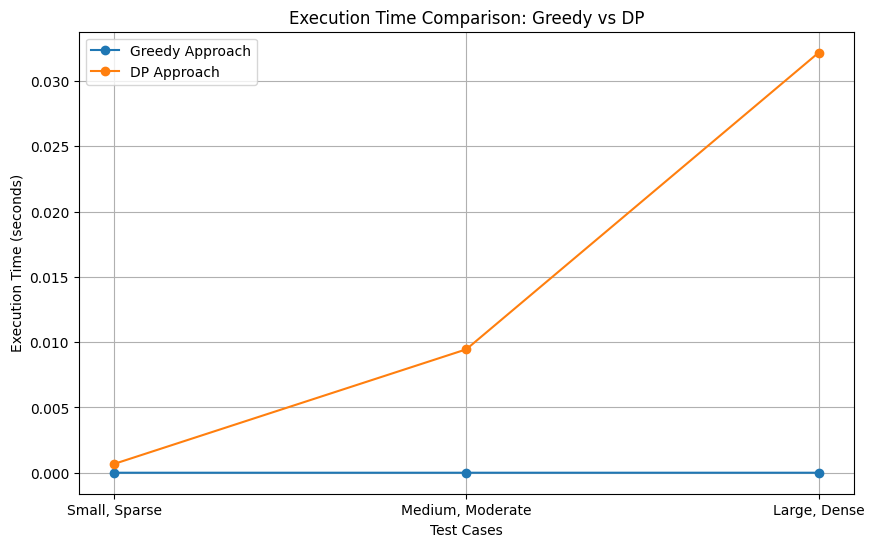

In [ ]:
#Creating a graph to see how two approaches scale when n of tasks increases

import random
import time
import matplotlib.pyplot as plt

def generate_tasks(num_tasks, max_duration, max_dependencies):
    """
    Generates a list of random tasks for testing.
    """
    tasks = []
    for i in range(num_tasks):
        dependencies = random.sample(range(i), k=random.randint(0, min(i, max_dependencies)))
        task = Task(
            id=i,
            description=f"Task {i}",
            duration=random.randint(1, max_duration),
            dependencies=dependencies,
            importance=random.randint(1, 10),
            probability_of_success=random.uniform(0.5, 1.0),
        )
        tasks.append(task)
    return tasks


def measure_execution_time(scheduler_class, tasks, *args):
    """
    Measures the execution time of a scheduling approach.

    Parameters
    ----------
    scheduler_class : class
        The scheduler class to test (e.g., Greedy or DP).
    tasks : list of Task
        List of tasks to schedule.
    *args : tuple
        Additional arguments for the scheduler.

    Returns
    -------
    float
        Execution time in seconds.
    """
    scheduler = scheduler_class(tasks)
    start_time = time.time()
    if scheduler_class == TaskScheduler:
        scheduler.run_task_scheduler
    elif scheduler_class == TaskSchedulerDP:
        scheduler.calculate_dp_schedule(*args)
    end_time = time.time()
    return end_time - start_time


#Test Cases
test_cases = [
    {"num_tasks": 10, "max_duration": 30, "max_dependencies": 2, "total_allowed_time": 100},  # Small
    {"num_tasks": 50, "max_duration": 30, "max_dependencies": 5, "total_allowed_time": 300}, # Medium
    {"num_tasks": 100, "max_duration": 30, "max_dependencies": 20, "total_allowed_time": 500} # Large
]

#Collecting Results
greedy_times = []
dp_times = []

for case in test_cases:
    tasks = generate_tasks(case["num_tasks"], case["max_duration"], case["max_dependencies"])
    total_time = case["total_allowed_time"]

    #Measure Greedy Execution Time
    greedy_time = measure_execution_time(TaskScheduler, tasks, total_time)
    greedy_times.append(greedy_time)

    #Measure DP Execution Time
    dp_time = measure_execution_time(TaskSchedulerDP, tasks, total_time)
    dp_times.append(dp_time)

#Ploting the Results
labels = ["Small, Sparse", "Medium, Moderate", "Large, Dense"]
x = range(len(test_cases))

plt.figure(figsize=(10, 6))
plt.plot(x, greedy_times, label="Greedy Approach", marker="o")
plt.plot(x, dp_times, label="DP Approach", marker="o")
plt.xticks(x, labels)
plt.xlabel("Test Cases")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison: Greedy vs DP")
plt.legend()
plt.grid(True)
plt.show()
